### Data Preprocessing, Feature Engineering and EDA

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import math
from scipy.stats import chi2_contingency

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

\Loading the data

In [133]:
df = pd.read_csv(r'C:\NG\Hospital Readmission Risk Prediction\Data\Raw\hospital_readmission_dataset.csv')

In [134]:
df.head()

,patient_id,patient_age,gender,marital_status,admission_type,department,diagnosis,secondary_diagnosis,blood_pressure,glucose_level,heart_rate,bmi,previous_admissions,previous_emergency_visits,hospital_stay_days,insurance_type,medication_count,lab_test_count,doctor_rating,followup_compliance_score,hospital_bill_amount,admission_date,discharge_date,followup_date,readmission_notice_sent,readmission_confirmed,final_readmission_reason,readmitted
0,PAT0000000,69,Female,Single,Elective,Orthopedics,Diabetes,NaN,119,227.0,104,24.31,1,9,6,Self-Paid,18,24,10.0,43.0,₹125345,2024-11-12,2024-10-31,2026-11-20,No,Yes,NaN,1
1,PAT0000001,32,Male,Married,Emergency,Neurology,Asthma,Kidney Disease,122,100.0,80,19.29,8,6,6,Government,9,2,1.0,94.0,26391.0,2024-12-28,2025-05-15,2026-11-14,Yes,Yes,Infection,1
2,PAT0000002,89,Male,Divorced,Urgent,General Medicine,Hypertension,Kidney Disease,90,237.0,71,33.44,0,5,10,Self-Paid,12,18,4.0,18.0,NaN,2023-10-12,2023-06-25,2026-07-13,Yes,Yes,Medication Issue,1
3,PAT0000003,78,Male,Single,Elective,Pulmonology,Infection,NaN,127,NaN,55,39.48,0,13,7,Government,3,3,10.0,12.0,61112.0,2025-07-27,2025-05-02,07-26-2026,No,No,NaN,1
4,PAT0000004,38,male,Single,Elective,Neurology,Asthma,Diabetes,92,74.0,83,28.18,2,6,16,Corporate,19,26,4.0,NaN,NaN,2023-11-15,2026-01-29,2026-07-22,No,No,Medication Issue,1


In [135]:
df.shape

(50500, 28)

 \Remove Duplicates

In [136]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(50000, 28)

### Insights
- 500 exact duplicate rows removed, dropping the dataset from 50,500 to 50,000.
- All duplicates were full-row copies — same `patient_id`, same values across all 28 columns.
- The pattern points to a double-write in the data pipeline, not actual repeat patient admissions.
- ~1% rate is low but still meaningful at this scale — 500 extra copies would skew class ratios and inflate training set size artificially.

\Fixing Invalid values

In [137]:
df.loc[(df['patient_age']<0) | (df['patient_age']>120), 'patient_age']=np.nan
df.loc[df['heart_rate']>250,'heart_rate'] =np.nan 
df.loc[df['bmi']<10 ,'bmi'] = np.nan

### Insights
- Ages outside 0–120, heart rates above 250, and BMI below 10 were nulled — these aren't statistical outliers, they're physiologically impossible values.
- Nulling instead of row-dropping keeps all other valid columns per row intact; row-dropping would waste 25+ real data points on a single bad entry.
- 202 bad ages and ~101 bad BMI entries were caught — small enough relative to 50K rows that column distributions remain unchanged.
- Thresholds were set on physiological bounds, not percentile cutoffs.

\Standardize categorical values

In [138]:
gender_map = {
    'male': 'Male', 'M': 'Male', 'MALE': 'Male', 'Male': 'Male',
    'female': 'Female', 'F': 'Female', 'FEMALE': 'Female', 'Female': 'Female'
}
df['gender']=df['gender'].map(gender_map)

### Insights
- `gender` had 4 casing/abbreviation variants for Male (`male`, `M`, `MALE`, `Male`) — all resolved via a single `.map()` call.
- Every other categorical column was already consistent; `gender` was the only field missing input validation at the source system.
- Post-mapping, the column is a clean binary field with no unmapped entries — the map covered all raw variants in the data.

\Cleaning Currency Columns

In [139]:
df['hospital_bill_amount']=df['hospital_bill_amount'].astype(str).str.replace('?','',regex=False)
df['hospital_bill_amount']=pd.to_numeric(df['hospital_bill_amount'],errors= 'coerce')

### Insights
- `hospital_bill_amount` had ₹-prefixed strings mixed with plain numeric values — the symbol had to be stripped before casting to float.
- After stripping, any remaining non-numeric strings coerce to `NaN` via `errors='coerce'` and flow into median imputation downstream.
- No regex was needed — a simple single-character `.str.replace()` was enough to fix the entire formatting issue.
- This was one of the type-mismatch columns flagged in the data quality audit; this step resolves it at the source.

\Convert Date Columns

In [140]:
date_cols = ['admission_date', 'discharge_date', 'followup_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce',format='mixed')

print(df[date_cols].dtypes)    

admission_date    datetime64[us]
discharge_date    datetime64[us]
followup_date     datetime64[us]
dtype: object


### Insights
- All three date columns now return `datetime64[us]` — confirmed from the dtypes print output, parse was successful across all records.
- `format='mixed'` handled both `YYYY-MM-DD` and `MM-DD-YYYY` variants in a single pass; `followup_date` was the only column with mixed formats (~3,035 records).
- Proper datetime objects allow direct subtraction for `length_of_stay` and `followup_delay` without additional string parsing.
- `errors='coerce'` ensures any remaining unparseable dates become `NaN` rather than raising an exception mid-run.

\Handle Missing Values

In [141]:
numeric_missing_cols= df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()]
numeric_missing_cols

Index(['patient_age', 'glucose_level', 'heart_rate', 'bmi', 'doctor_rating',
       'followup_compliance_score', 'hospital_bill_amount'],
      dtype='str')

In [142]:
for col in numeric_missing_cols:
    median_value=df[col].median()
    df[col]=df[col].fillna(median_value)

In [143]:
df['secondary_diagnosis']=df['secondary_diagnosis'].fillna(None)

### Insights
- 7 numeric columns had NaN values — `patient_age`, `glucose_level`, `heart_rate`, `bmi`, `doctor_rating`, `followup_compliance_score`, and `hospital_bill_amount` — all filled with their column medians.
- Median over mean is the right call: `hospital_bill_amount` has skewness 30.49, where the mean (~₹1.13L) sits noticeably above the true center (~₹1.03L median) due to extreme high-end bills.
- `secondary_diagnosis` NaN was filled with Python `None` — treating missing as "no secondary condition" is semantically correct and handled differently from numeric NaN downstream.
- No column missing rates were high enough to justify removal; even the highest share was structurally expected.

### Feature Engineering

\Date features

In [144]:
df['length_of_stay'] = (df['discharge_date'] - df['admission_date']).dt.days

print(df['length_of_stay'].head())

0    -12
1    138
2   -109
3    -86
4    806
Name: length_of_stay, dtype: int64


In [145]:
mask = df['length_of_stay'] < 0
df.loc[mask, ['admission_date','discharge_date']] = df.loc[mask, ['discharge_date','admission_date']].values

df['length_of_stay'] = (df['discharge_date'] - df['admission_date']).dt.days

print("Negative count after fix:", (df['length_of_stay'] < 0).sum())

Negative count after fix: 0


### Insights
- Some records had `admission_date` and `discharge_date` swapped, producing negative stay lengths — swapping column values in-place brought the negative count to exactly 0.
- Values like -12 and -109 days in the initial print confirmed this was a systematic entry error, not a few isolated bad rows.
- Fixing the dates in-place preserves the actual stay duration; nulling would have permanently discarded valid clinical data for those records.

In [146]:
df['followup_delay'] = (df['followup_date'] - df['discharge_date']).dt.days
print(df['followup_delay'].describe())

count    50000.000000
mean       454.579900
std        263.860379
min       -170.000000
25%        237.000000
50%        413.000000
75%        641.000000
max       1265.000000
Name: followup_delay, dtype: float64


### Insights
- `followup_delay` ranges from -170 to 1,265 days — negative values mean `followup_date` was logged before `discharge_date`, which is a data entry error.
- Median of 413 days means most patients wait over a year between discharge and followup, likely because the dataset spans multiple collection years rather than reflecting clinical scheduling.
- The std of 264 days is nearly as large as the mean (455 days), making this a wide, noisy feature with limited reliability as a raw predictor.

In [147]:
df['admission_month'] = df['admission_date'].dt.month  
df['admission_year']  = df['admission_date'].dt.year   

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['admission_season'] = df['admission_month'].apply(get_season)

print(df['admission_season'].value_counts())

admission_season
Monsoon         20205
Winter          11261
Summer           9654
Post-Monsoon     8880
Name: count, dtype: int64


### Insights
- Monsoon (Jun–Sep) accounts for 20,205 admissions (40.4%) — nearly 2.3× the quietest quarter, Post-Monsoon (8,880).
- Winter (Dec–Feb) is second at 22.5%, creating a dual-peak pattern: one in monsoon, one in colder months.
- The seasonal skew aligns with Indian healthcare patterns — monsoon drives waterborne and respiratory illness spikes, winter aggravates chronic conditions.
- Admission season encodes real-world disease seasonality and is worth keeping as a categorical predictor rather than treating it as a date artifact.

\Others useful features

In [148]:
df['total_risk_history'] = df['previous_admissions'] + df['previous_emergency_visits']
print(df['total_risk_history'].describe())

count    50000.000000
mean        11.562660
std          5.995131
min          0.000000
25%          8.000000
50%         11.000000
75%         15.000000
max        114.000000
Name: total_risk_history, dtype: float64


### Insights
- Mean of 11.6 and max of 114, but median of 11 — right-skewed (skewness 4.05), pulled by a small cohort of extreme high-utilization patients.
- Combining `previous_admissions` + `previous_emergency_visits` into one score reduces two inputs to a single prior-burden signal without losing information from either.
- The max of 114 is a clear outlier — chronic cases at that level likely have different readmission dynamics than the typical patient.
- Both source columns are essentially uncorrelated (~0.00) with each other, so combining them doesn't create a redundant feature.

In [149]:
df['has_secondary_diagnosis'] = (df['secondary_diagnosis'].notna() & 
                                  (df['secondary_diagnosis'] != 'None')).astype(int)

print(df['has_secondary_diagnosis'].value_counts())

has_secondary_diagnosis
1    37410
0    12590
Name: count, dtype: int64


### Insights
- 74.8% of patients (37,410) have a secondary diagnosis — comorbidity is the norm in this dataset, not the exception.
- Single-condition admissions (12,590 records, 25.2%) are the atypical case; `has_secondary_diagnosis = 0` is the more informative flag value.
- The binary captures presence/absence cleanly, but the specific secondary condition (Kidney Disease vs. Diabetes) carries additional signal worth encoding separately at the modeling stage.

In [150]:
def bp_category(bp):
    if bp < 90:
        return 'Low'
    elif bp <= 120:
        return 'Normal'
    elif bp <= 140:
        return 'Elevated'
    else:
        return 'High'

df['bp_category'] = df['blood_pressure'].apply(bp_category)
print(df['bp_category'].value_counts())

bp_category
High        19268
Normal      15631
Elevated    10020
Low          5081
Name: count, dtype: int64


### Insights
- High BP (>140 mmHg) is the largest group at 38.5% (19,268) — systemic hypertension is the dominant blood pressure state in this cohort.
- High + Elevated (>120 mmHg) together cover 58.6% of patients — over half the dataset is operating above normal pressure.
- Low BP at 10.2% (5,081) is the smallest category, expected for an inpatient population skewed toward chronic illness.
- Binning converts a near-uniform continuous distribution into a clinically interpretable ordinal feature with direct meaning.

In [151]:
df['medication_intensity'] = df['medication_count'] / (df['lab_test_count'] + 1)
df['medication_intensity'].head()

0    0.720000
1    3.000000
2    0.631579
3    0.750000
4    0.703704
Name: medication_intensity, dtype: float64

In [152]:
df['low_compliance'] = (df['followup_compliance_score'] < 50).astype(int)
df['low_compliance'].value_counts()


low_compliance
0    29224
1    20776
Name: count, dtype: int64

### Insights
- 41.5% of patients (20,776) scored below 50 on followup compliance — nearly half the dataset has weak post-discharge engagement.
- The 41.5/58.5 split is fairly balanced, so this flag won't carry the class imbalance issues that affect the target variable.
- Post-discharge compliance directly encodes a behavioral risk pattern — patients who don't follow up tend to deteriorate undetected.
- The cutoff of 50 on a 0–100 scale treats "below half" as the threshold for clinically meaningful low compliance.

\EDA

\Target Distribution

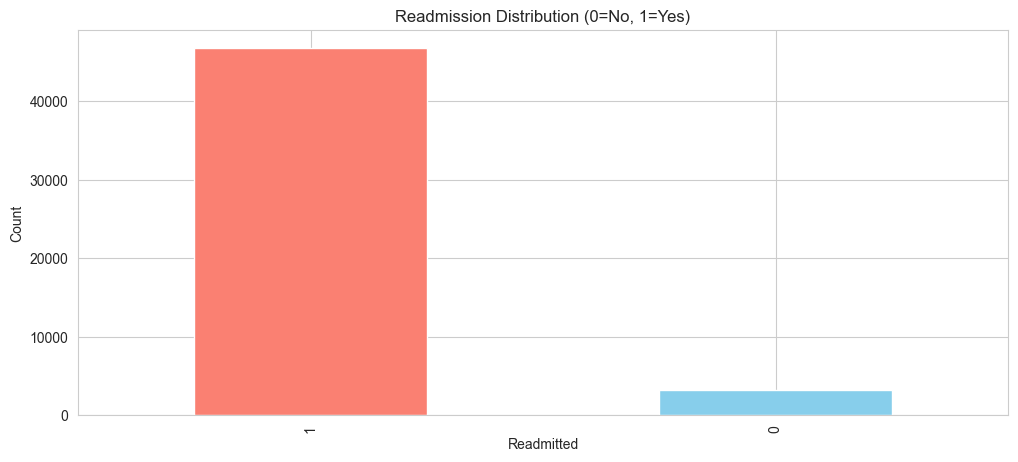

readmitted
1    93.566
0     6.434
Name: proportion, dtype: float64


In [153]:
df['readmitted'].value_counts().plot(kind='bar', color=['salmon','skyblue'])
plt.title('Readmission Distribution (0=No, 1=Yes)')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.savefig(
    r'C:\NG\Hospital Readmission Risk Prediction\reports\readmission_distribution.png',
    bbox_inches='tight'
)
plt.show()

print(df['readmitted'].value_counts(normalize=True) * 100)

### Insights
- The target is 93.566% class 1 (readmitted) vs. 6.434% class 0 — a roughly 14.5:1 imbalance ratio.
- The chart makes this stark: the salmon bar (~46,800) towers over the blue bar (~3,200) with almost no visual comparison between the two.
- A naive model predicting "always readmitted" would hit 93.6% accuracy — making raw accuracy a useless metric for this problem.
- Class weighting, SMOTE, or stratified splits will be essential before training any classifier on this data.

\Univariate Analysis

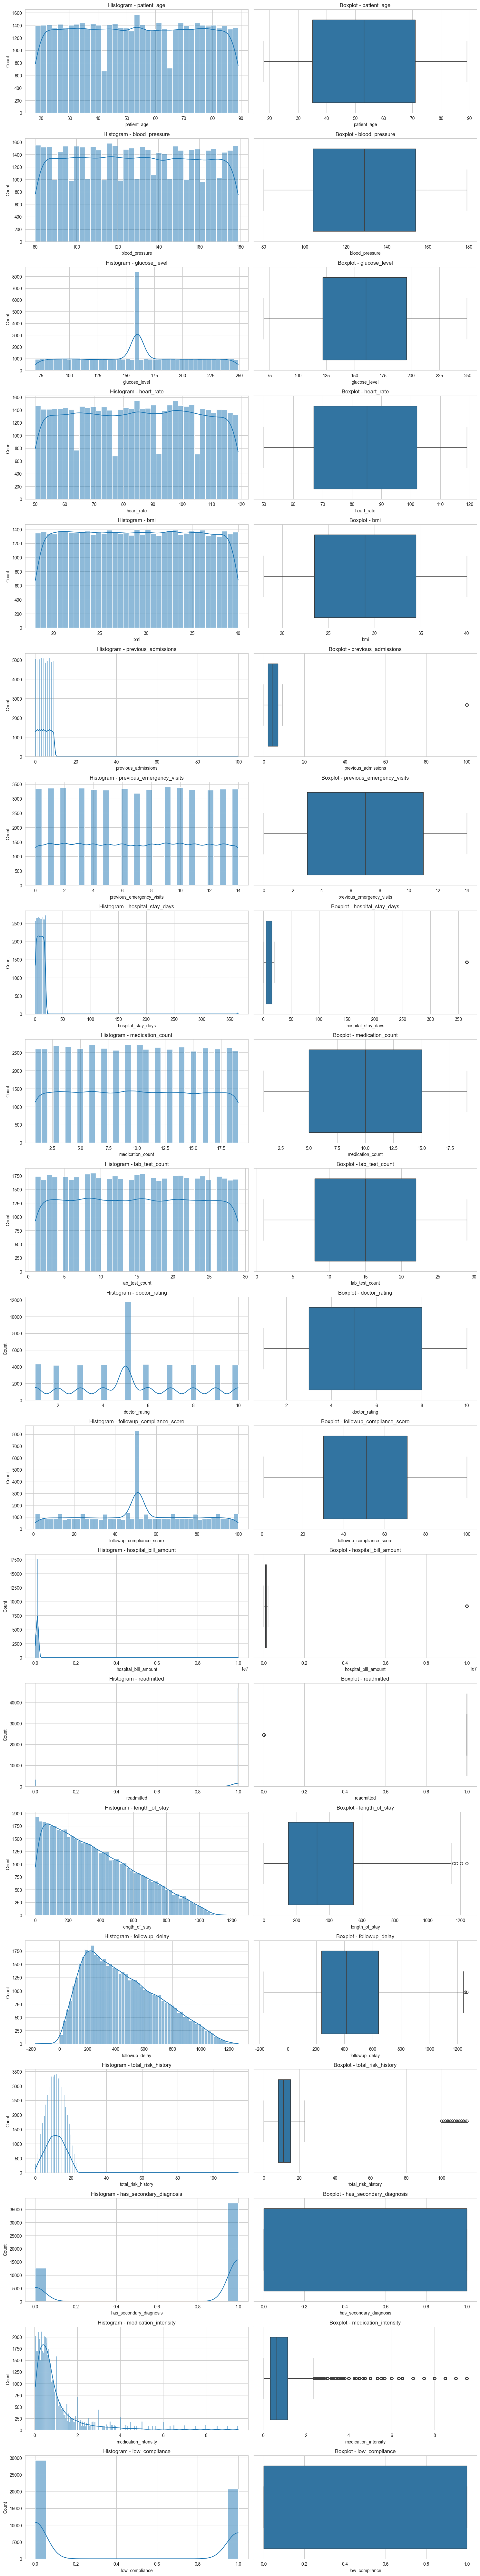

In [154]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_rows = len(numeric_cols)

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(15, 4 * n_rows)
)

if n_rows == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):

    # Histogram
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i][0]
    )

    axes[i][0].set_title(f'Histogram - {col}')

    # Boxplot
    sns.boxplot(
        x=df[col],
        ax=axes[i][1]
    )

    axes[i][1].set_title(f'Boxplot - {col}')

plt.tight_layout()

plt.savefig(
    r'C:\NG\Hospital Readmission Risk Prediction\reports\numeric_univariate_analysis.png',
    bbox_inches='tight'
)

plt.show()

### Insights
- `patient_age`, `blood_pressure`, `glucose_level`, `heart_rate`, and `bmi` are all near-symmetric — the histograms show bell-curve shapes; these features are model-ready without any transformation.
- `previous_admissions` and `hospital_stay_days` have severe right tails — the boxplots show most values compressed near the lower quartile with a long outlier whisker pulling the skewness to ~12 and ~22.9 respectively.
- `hospital_bill_amount` is the most extreme at skewness ~30.49 — the box is near zero with a whisker stretching toward ₹1Cr; this column needs log-transformation for any linear model.
- `readmitted` has mean 0.936 — its histogram is essentially a spike at 1, visually confirming the 93.6% class imbalance.
- `medication_intensity` and `total_risk_history` are right-skewed engineered features worth log-transforming alongside the raw clinical columns.
- `followup_compliance_score` histogram is roughly flat — no natural clustering at either the high or low compliance end.

\Categorical univariate analysis

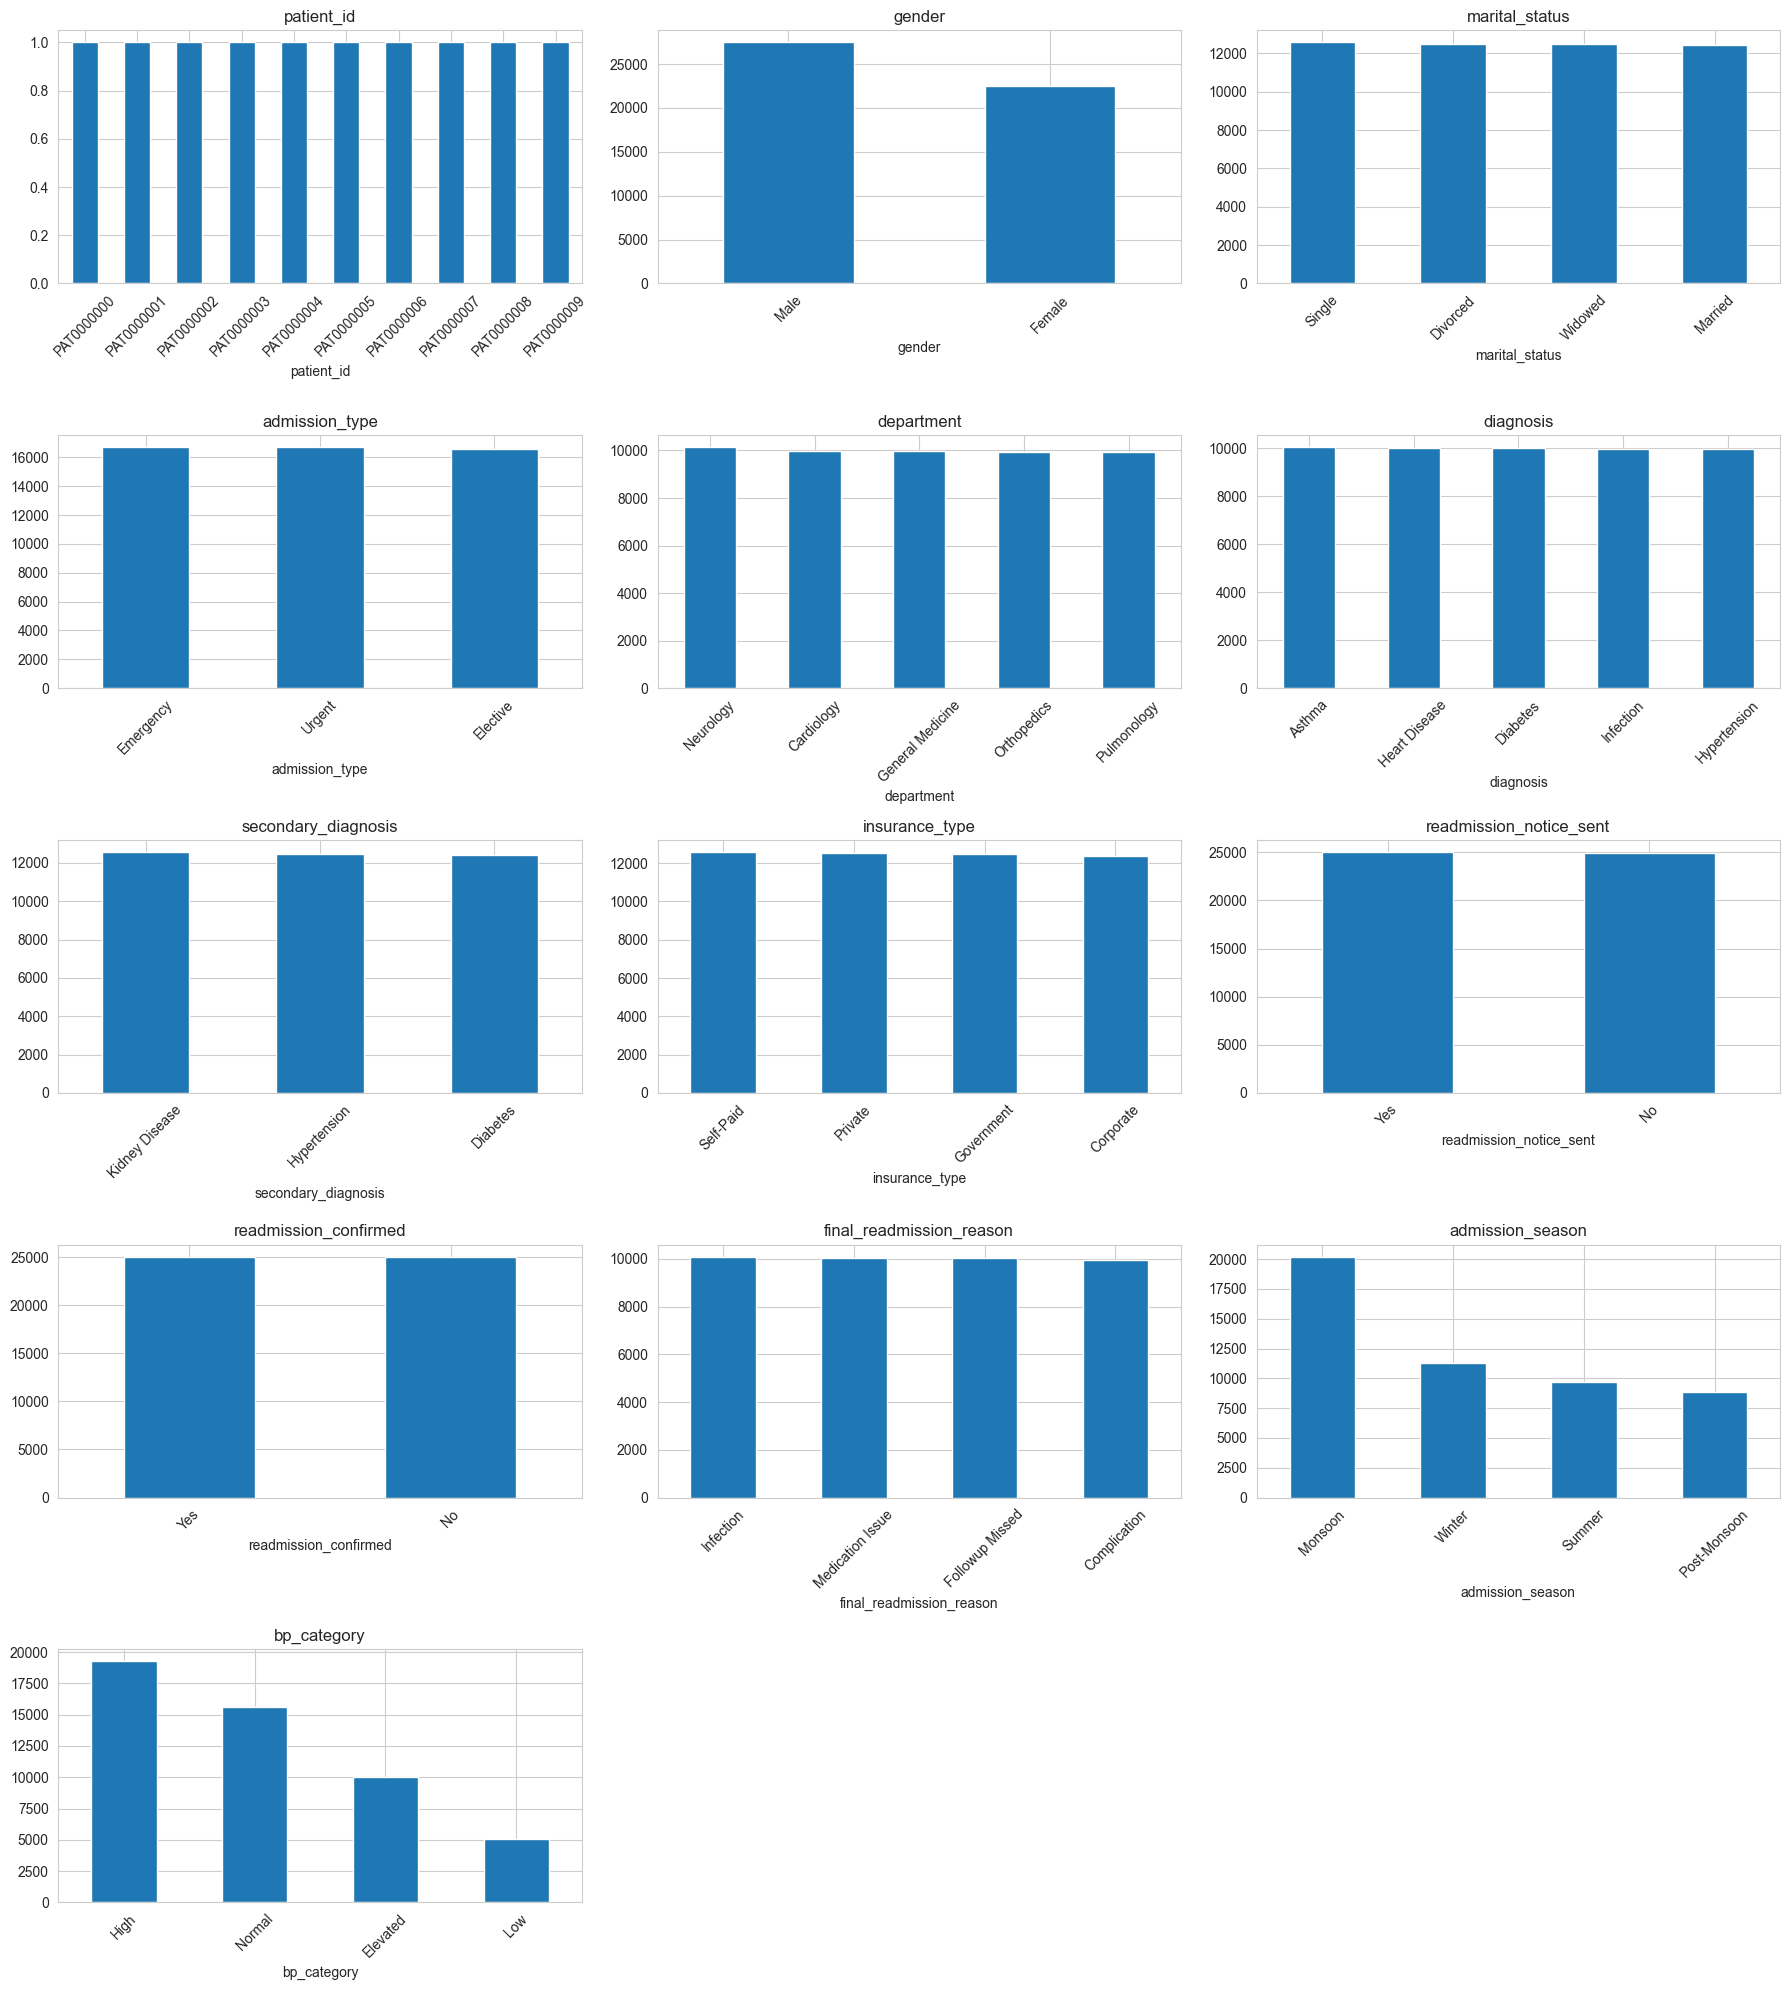

In [155]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().head(10).plot(
        kind='bar',
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    r'C:\NG\Hospital Readmission Risk Prediction\reports\categorical_univariate_analysis.png',
    bbox_inches='tight'
)

plt.show()

### Insights
- `gender` is nearly a 50/50 Male/Female split — no gender skew to account for in modeling.
- `admission_type`, `marital_status`, `insurance_type`, `department`, and `diagnosis` all show roughly equal bar heights — no single dominant category in any of these.
- `readmission_confirmed` is visually dominated by "Yes" — consistent with the 93.6% readmission rate in the target.
- `admission_season` is the only visibly uneven categorical: the Monsoon bar is clearly taller than the other three seasons combined.
- `bp_category` shows "High" as the tallest bar followed by "Normal", aligning with the 38.5% figure from the feature engineering step.
- `final_readmission_reason` has a visible empty/None bar since ~25% of records have no reason logged — those are the non-readmitted cases.

\Multivariate Analysis

\Numeric Multivariate Analysis

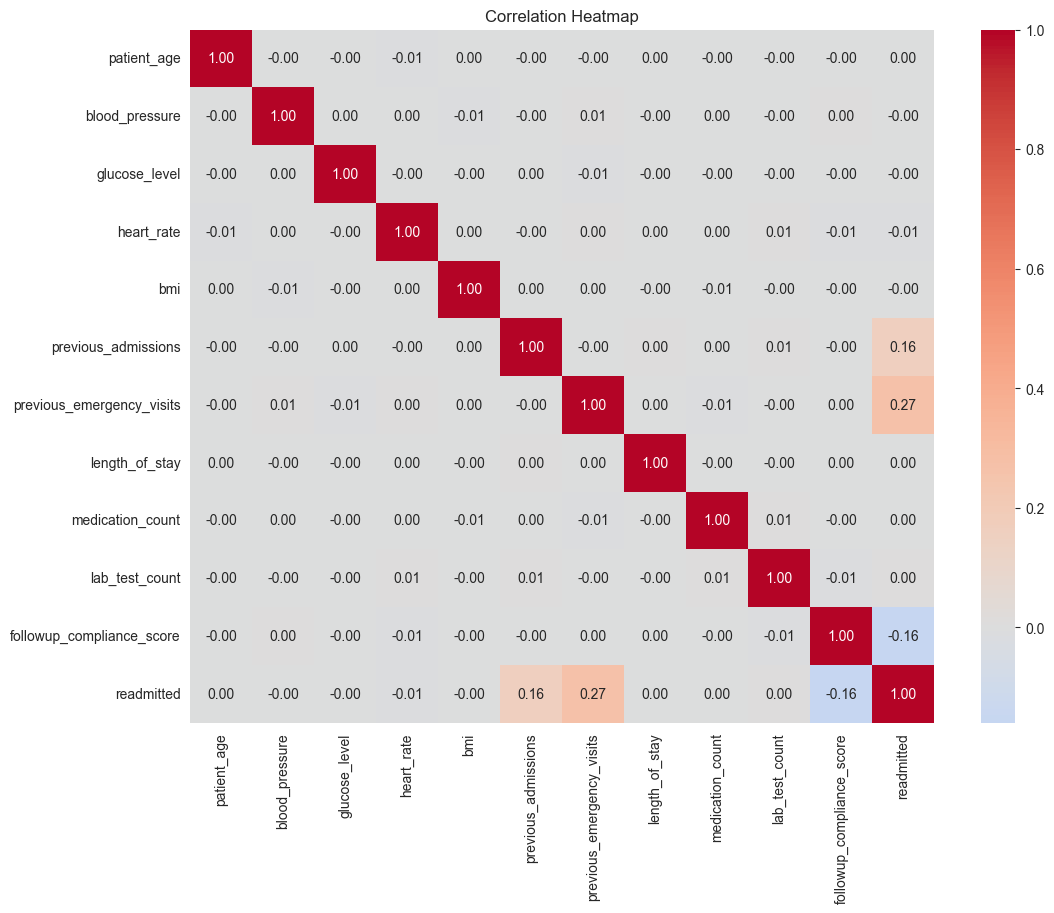

In [156]:
num_cols = ['patient_age','blood_pressure','glucose_level','heart_rate','bmi',
            'previous_admissions','previous_emergency_visits','length_of_stay',
            'medication_count','lab_test_count','followup_compliance_score','readmitted']

corr_matrix_numeric=df[num_cols].corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix_numeric, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.savefig(
    r'C:\NG\Hospital Readmission Risk Prediction\reports\numeric_multivariate_analysis.png',
    bbox_inches='tight'
)
plt.show()

### Insights
- `previous_emergency_visits` has the highest correlation with `readmitted` at 0.27 — the strongest numeric predictor in the entire feature set.
- `previous_admissions` and `followup_compliance_score` follow at 0.16 and -0.16 — prior hospital use and poor compliance are the two numeric signal directions for readmission risk.
- All five clinical vitals (age, blood_pressure, glucose_level, heart_rate, bmi) show ~0.00 correlation with `readmitted` — no meaningful linear signal from raw physiological measurements alone.
- `previous_admissions` and `previous_emergency_visits` are essentially uncorrelated with each other (~0.00), so their combined feature `total_risk_history` doesn't create redundancy.
- `medication_count` and `lab_test_count` also sit at ~0.01 — no collinearity concern between these two treatment-intensity features.
- The entire numeric feature space is nearly orthogonal, which is good for linear model stability but suggests real predictive signal likely lives in non-linear combinations.

\Categorical Multivariate Analysis

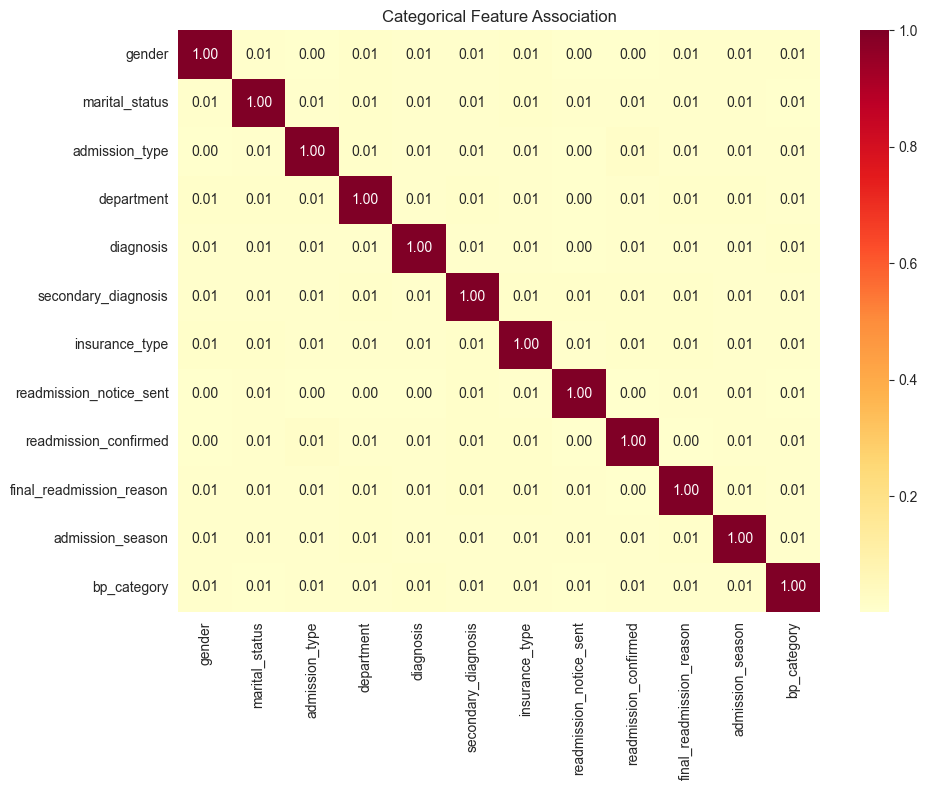

In [157]:
cat_cols_filtered = [
    col for col in cat_cols
    if df[col].nunique() <= 20
]

def cramers_v(x, y):

    confusion = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion)[0]

    n = confusion.sum().sum()

    r, k = confusion.shape

    return np.sqrt(
        chi2 / (n * (min(r, k) - 1))
    )

cramers_matrix = pd.DataFrame(
    index=cat_cols_filtered,
    columns=cat_cols_filtered
)

for col1 in cat_cols_filtered:
    for col2 in cat_cols_filtered:

        cramers_matrix.loc[col1, col2] = (
            cramers_v(df[col1], df[col2])
        )

cramers_matrix = cramers_matrix.astype(float)

plt.figure(figsize=(10,8))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap='YlOrRd',
    fmt='.2f'
)

plt.title("Categorical Feature Association")
plt.tight_layout()
plt.savefig(
    r'C:\NG\Hospital Readmission Risk Prediction\reports\categorical_multivariate_analysis.png',
    bbox_inches='tight'
)
plt.show()

### Insights
- Every off-diagonal cell shows Cramér's V of 0.00–0.01 — the entire heatmap is uniformly yellow, meaning the categorical features are essentially independent of one another.
- Even `readmission_notice_sent` × `readmission_confirmed` scores 0.00 — though both are dropped as leakage columns anyway, this confirms they don't share information through indirect categorical paths.
- `diagnosis` and `department` score 0.01 — no detectable routing logic (e.g., Asthma → Pulmonology) was preserved in the data.
- Zero inter-categorical correlation means no multicollinearity concern regardless of encoding strategy — one-hot or target encoding will produce independent columns.

\Removing Data Leakage

In [158]:
leakage_cols = ['readmission_notice_sent', 'readmission_confirmed', 'final_readmission_reason']
df = df.drop(columns=leakage_cols)
print(" Leakage columns dropped. Remaining columns:", df.shape[1])

 Leakage columns dropped. Remaining columns: 35


\Removing Unwanted columns

In [159]:
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

In [160]:
date_cols = ['admission_date', 'discharge_date', 'followup_date']
df = df.drop(columns=[c for c in date_cols if c in df.columns])

\Saving the Processed Data

In [161]:
df.to_csv(r'C:\NG\Hospital Readmission Risk Prediction\Data\Processed\cleaned_hospital_data.csv', index=False)
print(" Shape:", df.shape)

 Shape: (50000, 31)
